# Regresión Logística Binaria - Predicción de Incumplimiento de Pago

## Descripción

En este laboratorio se implementa un modelo de regresión logística binaria para predecir si un cliente incumplirá o no con el pago correspondiente al próximo mes.

El dataset utilizado contiene 30.000 ejemplos y 23 características predictoras, cumpliendo con los requisitos establecidos de al menos 20.000 ejemplos (m ≥ 20000) y 20 propiedades (n ≥ 20).

La variable objetivo utilizada es `default payment next month`, donde:

- **0:** el cliente no incumple el pago.
- **1:** el cliente incumple el pago.

Para el desarrollo se utiliza Pandas en el preprocesamiento de los datos. Posteriormente, los datos se dividen en 80% para entrenamiento y 20% para prueba. El modelo de regresión logística se entrena mediante descenso de gradiente, determinando los parámetros θ y analizando la convergencia mediante la función de costo.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Preprocesamiento de datos

Se utiliza Pandas para cargar, organizar y preparar el dataset antes del entrenamiento del modelo.

In [4]:
# Manejo de datos
import pandas as pd

# Cálculo científico y vectorial
import numpy as np

# Librerías para graficar
from matplotlib import pyplot

# Módulo de optimización
from scipy import optimize

# Mostrar gráficos dentro del cuaderno
%matplotlib inline

In [5]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab04/default of credit card clients.xls')

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [6]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset:
(30001, 25)

Nombres de las columnas:
['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']

Tipos de datos:
Unnamed: 0    object
X1            object
X2            object
X3            object
X4            object
X5            object
X6            object
X7            object
X8            object
X9            object
X10           object
X11           object
X12           object
X13           object
X14           object
X15           object
X16           object
X17           object
X18           object
X19           object
X20           object
X21           object
X22           object
X23           object
Y             object
dtype: object


In [7]:
pd.set_option('display.max_columns', None)

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [8]:
df.iloc[:5]

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [9]:
# Usar la primera fila como nombres reales de las columnas
df.columns = df.iloc[0]

# Eliminar esa primera fila, porque ya no es un ejemplo
df = df.iloc[1:].reset_index(drop=True)

# Mostrar las primeras filas
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 25)

Columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [11]:
# Convertir todas las columnas a tipo numérico
df = df.apply(pd.to_numeric, errors='coerce')

print(df.dtypes)

0
ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object


In [12]:
print("Total de valores nulos:")
print(df.isnull().sum().sum())

Total de valores nulos:
0


## 2. Preparación de variables

Se separan las 23 características predictoras (X) de la variable objetivo (y). La columna ID se elimina debido a que solo funciona como identificador.

In [13]:
# Variable objetivo
y = df['default payment next month']

# Variables predictoras
X = df.drop(columns=['default payment next month'])

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nValores de la variable objetivo:")
print(y.value_counts())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Valores de la variable objetivo:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


In [14]:
y.value_counts()

,count
default payment next month,
0,23364
1,6636


In [15]:
X = X.drop(columns=['ID'])

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000,)


In [16]:
from sklearn.model_selection import train_test_split

## 3. División de datos

Se utiliza el 80% de los datos para entrenar el modelo y el 20% restante para realizar la validación.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print("X entrenamiento:", X_train.shape)
print("y entrenamiento:", y_train.shape)

print("\nX prueba:", X_test.shape)
print("y prueba:", y_test.shape)

X entrenamiento: (24000, 23)
y entrenamiento: (24000,)

X prueba: (6000, 23)
y prueba: (6000,)


## 4. Normalización de los datos

Las características se estandarizan para trabajar en escalas comparables y mejorar la convergencia del descenso de gradiente.

In [19]:
from sklearn.preprocessing import StandardScaler

# Crear el normalizador
scaler = StandardScaler()

# Aprender la media y desviación SOLO con entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación a prueba
X_test_scaled = scaler.transform(X_test)

print("X_train normalizado:", X_train_scaled.shape)
print("X_test normalizado:", X_test_scaled.shape)

X_train normalizado: (24000, 23)
X_test normalizado: (6000, 23)


In [20]:
# Agregar una columna de unos para el término independiente theta_0

X_train_bias = np.concatenate(
    [np.ones((X_train_scaled.shape[0], 1)), X_train_scaled],
    axis=1
)

X_test_bias = np.concatenate(
    [np.ones((X_test_scaled.shape[0], 1)), X_test_scaled],
    axis=1
)

print("X_train con intercepto:", X_train_bias.shape)
print("X_test con intercepto:", X_test_bias.shape)

X_train con intercepto: (24000, 24)
X_test con intercepto: (6000, 24)


## 5. Modelo de Regresión Logística

Se agrega el término de intercepto y se implementa la función sigmoide, utilizada para obtener probabilidades entre 0 y 1.

In [21]:
# Función sigmoide
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

In [22]:
print(sigmoid(0))
print(sigmoid(2))
print(sigmoid(-2))

0.5
0.8807970779778823
0.11920292202211755


## 6. Función de costo y entrenamiento

Se utiliza la función de costo de regresión logística para medir el error del modelo. Los parámetros θ se actualizan mediante descenso de gradiente hasta reducir y estabilizar el costo.

In [23]:
def calcularCosto(theta, X, y):
    m = y.size

    # Probabilidades calculadas por el modelo
    h = sigmoid(X.dot(theta))

    # Evitar log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)

    # Calcular el costo
    J = -(1 / m) * np.sum(
        y * np.log(h) +
        (1 - y) * np.log(1 - h)
    )

    return J

In [24]:
def calcularCosto(theta, X, y):
    m = y.size

    # Probabilidades calculadas por el modelo
    h = sigmoid(X.dot(theta))

    # Evitar log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)

    # Calcular el costo
    J = -(1 / m) * np.sum(
        y * np.log(h) +
        (1 - y) * np.log(1 - h)
    )

    return J

In [25]:
# Crear los 24 parámetros theta inicializados en 0
theta_inicial = np.zeros(X_train_bias.shape[1])

# Calcular costo inicial
costo_inicial = calcularCosto(
    theta_inicial,
    X_train_bias,
    y_train.to_numpy()
)

print("Cantidad de parámetros theta:", len(theta_inicial))
print("Costo inicial:", costo_inicial)

Cantidad de parámetros theta: 24
Costo inicial: 0.6931471805599452


In [26]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]

    # Copia de theta para ir actualizando
    theta = theta.copy()

    # Aquí guardaremos el costo en cada iteración
    J_history = []

    for i in range(num_iters):

        # Predicción probabilística
        h = sigmoid(X.dot(theta))

        # Actualización de theta
        gradiente = (1 / m) * X.T.dot(h - y)

        theta = theta - alpha * gradiente

        # Guardar el costo
        costo = calcularCosto(theta, X, y)
        J_history.append(costo)

    return theta, J_history

In [27]:
alpha = 0.1
num_iters = 1000

theta_inicial = np.zeros(X_train_bias.shape[1])

theta_entrenado, J_history = descensoGradiente(
    theta_inicial,
    X_train_bias,
    y_train.to_numpy(),
    alpha,
    num_iters
)

print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])
print("Cantidad de parámetros theta:", len(theta_entrenado))

Costo inicial: 0.6787413517846709
Costo final: 0.4633506719984014
Cantidad de parámetros theta: 24


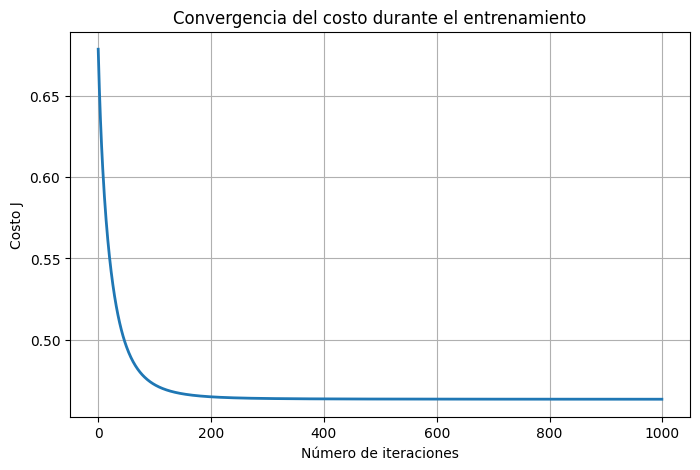

In [28]:
pyplot.figure(figsize=(8, 5))

pyplot.plot(
    np.arange(len(J_history)),
    J_history,
    lw=2
)

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo durante el entrenamiento')

pyplot.grid(True)
pyplot.show()

La grafica nos muestra que la funcion va disminuyendo como es de esperarse desde aprox. 0.68 hasta 0.46 lo cual nos indica que el descenso del gradiente esta ajustando correctamente los parametros de tita

## 7. Predicción y validación

El modelo entrenado se evalúa utilizando los 6000 ejemplos del conjunto de prueba, los cuales no participaron en el entrenamiento. Se utiliza un umbral de 0.5 para clasificar cada predicción como 0 o 1.

In [29]:
def predict(theta, X):
    # Calcular probabilidades
    probabilidades = sigmoid(X.dot(theta))

    # Convertir probabilidades en clases 0 o 1
    predicciones = (probabilidades >= 0.5).astype(int)

    return predicciones

In [30]:
y_pred = predict(theta_entrenado, X_test_bias)

print("Cantidad de predicciones:", len(y_pred))
print("Primeras 20 predicciones:")
print(y_pred[:20])

Cantidad de predicciones: 6000
Primeras 20 predicciones:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
print("Cantidad de predicciones 0:", np.sum(y_pred == 0))
print("Cantidad de predicciones 1:", np.sum(y_pred == 1))

accuracy = np.mean(y_pred == y_test.to_numpy()) * 100

print("Precisión del modelo: {:.2f}%".format(accuracy))

Cantidad de predicciones 0: 5540
Cantidad de predicciones 1: 460
Precisión del modelo: 80.78%


In [32]:
print("Valores reales en prueba:")
print(y_test.value_counts())

Valores reales en prueba:
default payment next month
0    4673
1    1327
Name: count, dtype: int64


In [33]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[4530  143]
 [1010  317]]


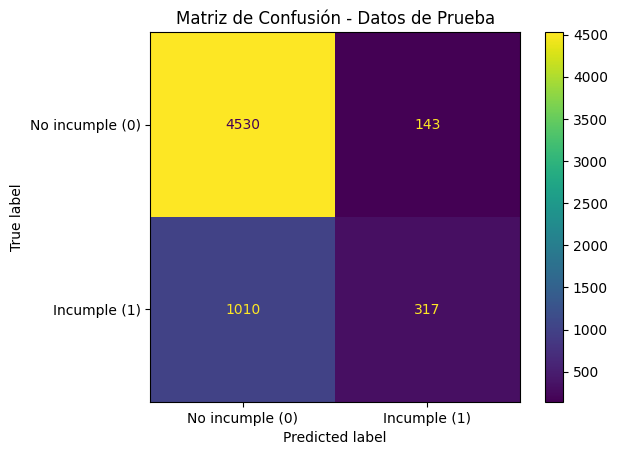

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['No incumple (0)', 'Incumple (1)']
)

disp.plot()

pyplot.title('Matriz de Confusión - Datos de Prueba')
pyplot.show()

El modelo que realizamos clasifico correctamente 4530 caso de la clase 0 y 317 caso de la clase 1 pero hay una pequeña dificultad para predecir la cantidad de cliente que incumpliran el pago, esto es debido al desbalance que presenta el dataset

In [35]:
from sklearn.metrics import classification_report

print("Reporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No incumple (0)', 'Incumple (1)']
    )
)

Reporte de clasificación:
                 precision    recall  f1-score   support

No incumple (0)       0.82      0.97      0.89      4673
   Incumple (1)       0.69      0.24      0.35      1327

       accuracy                           0.81      6000
      macro avg       0.75      0.60      0.62      6000
   weighted avg       0.79      0.81      0.77      6000



In [36]:
# Obtener probabilidades de pertenecer a la clase 1
probabilidades = sigmoid(X_test_bias.dot(theta_entrenado))

# Crear tabla con resultados
resultados = pd.DataFrame({
    'Valor real': y_test.to_numpy(),
    'Prediccion': y_pred,
    'Probabilidad clase 1': probabilidades
})

# Indicar si acertó
resultados['Correcto'] = (
    resultados['Valor real'] == resultados['Prediccion']
)

# Mostrar las primeras 20 predicciones
resultados.head(20)

,Valor real,Prediccion,Probabilidad clase 1,Correcto
0,0,0,0.110108,True
1,0,0,0.118169,True
2,0,0,0.219590,True
3,1,0,0.095560,False
4,0,0,0.027393,True
5,0,0,0.171205,True
6,0,0,0.148750,True
7,0,0,0.152496,True
8,0,0,0.086048,True
9,0,0,0.195991,True


## 8. Resultados

El modelo obtuvo una exactitud aproximada del 80,78% sobre los datos de prueba. La matriz de confusión y las métricas permiten observar que el modelo clasifica mejor la clase 0 que la clase 1.

In [37]:
# Nombres de las 23 características
nombres = ['Intercepto'] + X.columns.tolist()

# Crear tabla con los parámetros theta
tabla_theta = pd.DataFrame({
    'Parametro': ['theta_' + str(i) for i in range(len(theta_entrenado))],
    'Caracteristica': nombres,
    'Valor': theta_entrenado
})

tabla_theta

,Parametro,Caracteristica,Valor
0,theta_0,Intercepto,-1.463431
1,theta_1,LIMIT_BAL,-0.136804
2,theta_2,SEX,-0.055474
3,theta_3,EDUCATION,-0.097655
4,theta_4,MARRIAGE,-0.072284
5,theta_5,AGE,0.074352
6,theta_6,PAY_0,0.661870
7,theta_7,PAY_2,0.092489
8,theta_8,PAY_3,0.098942
9,theta_9,PAY_4,0.061362


In [38]:
print("Costo final del modelo:", J_history[-1])
print("Número de iteraciones:", len(J_history))
print("Número de parámetros theta:", len(theta_entrenado))

Costo final del modelo: 0.4633506719984014
Número de iteraciones: 1000
Número de parámetros theta: 24


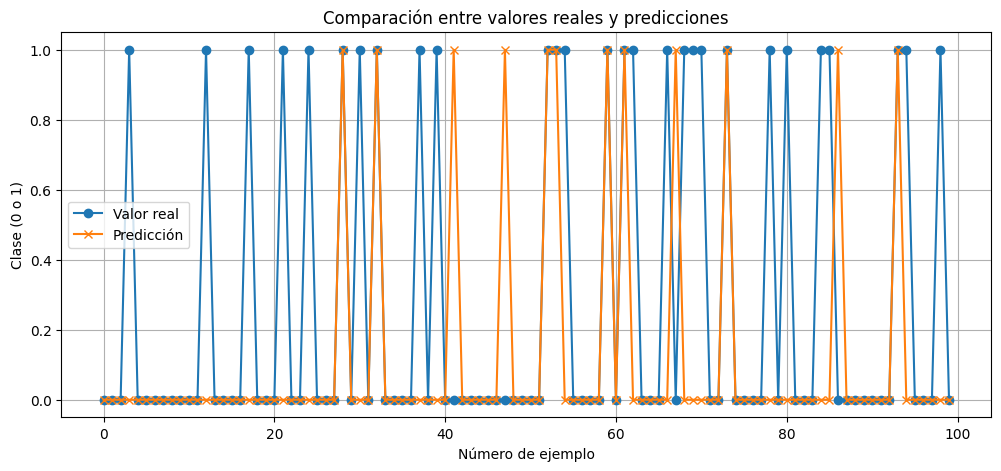

In [39]:
# Comparación de los primeros 100 valores reales y predichos

pyplot.figure(figsize=(12, 5))

pyplot.plot(
    np.arange(100),
    y_test.to_numpy()[:100],
    marker='o',
    label='Valor real'
)

pyplot.plot(
    np.arange(100),
    y_pred[:100],
    marker='x',
    label='Predicción'
)

pyplot.xlabel('Número de ejemplo')
pyplot.ylabel('Clase (0 o 1)')
pyplot.title('Comparación entre valores reales y predicciones')
pyplot.legend()
pyplot.grid(True)

pyplot.show()

La gráfica compara los valores reales con las predicciones realizadas por el modelo sobre una muestra de 100 ejemplos pertenecientes exclusivamente al conjunto de prueba. Las coincidencias entre ambas series representan clasificaciones correctas, mientras que las diferencias representan errores del modelo. Esta comparación permite observar visualmente el comportamiento de la regresión logística sobre datos que no fueron utilizados durante el entrenamiento.

## 9. Conclusión

Se implementó correctamente un modelo de regresión logística binaria utilizando 30.000 ejemplos y 23 características. El entrenamiento se realizó con el 80% de los datos y la validación con el 20% restante.

El descenso de gradiente permitió reducir el costo hasta aproximadamente 0,463 y obtener los parámetros θ del modelo. Finalmente, se alcanzó una exactitud aproximada del 80,78%, mostrando un desempeño aceptable en la clasificación.